In [ ]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def plot_learning(history):
    tgts = ['loss', 'acc']
    vtgts = ['val_loss', 'val_acc']
    plt.figure(figsize=(10,3))
    for i, (tgt, val_tgt) in enumerate(zip(tgts, vtgts)):
        plt.subplot(1,2, i+1)
        plt.plot(history.history[tgt], label=tgt)
        plt.plot(history.history[val_tgt], label=val_tgt)
        plt.xlabel('Epoch')
        plt.legend()
        plt.title(f"Training and validation {tgt}")

In [ ]:
#config
NUM_CLASSES= 10 # 10 for CIFAR-10
IMG_SIZE= 32
BATCH_SIZE = 128
EPOCHS = 25
PATCH_SIZE = 8  #ViT patch size
EMBED_DIM = 384
NUM_HEADS = 6
MLP_DIM = 768
NUM_LAYERS = 6
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.1
DROPPATH_RATE = 0.1
LABEL_SMOOTHING = 0.1

In [ ]:
# data: CIFAR-10/100
def load_cifar(num_classes=10):
    if num_classes == 10:
        (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    else:
        (x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data(label_mode="fine")
    y_train = y_train.squeeze()
    y_test  = y_test.squeeze()
    x_train = x_train.astype("float32") / 255.0
    x_test  = x_test.astype("float32") / 255.0
    return (x_train, y_train), (x_test, y_test)

(x_train, y_train), (x_test, y_test) = load_cifar(NUM_CLASSES)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [ ]:
# basic aug + randaugment-like
data_augmentation = keras.Sequential(
    [
        layers.Resizing(IMG_SIZE, IMG_SIZE),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation",
)

In [ ]:
def make_ds(x, y, training=True):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10000)
        ds = ds.map(
            lambda a, b: (data_augmentation(a), tf.one_hot(b, NUM_CLASSES)),
            num_parallel_calls=AUTOTUNE,
        )
    else:
        ds = ds.map(
            lambda a, b: (
                tf.image.resize(a, (IMG_SIZE, IMG_SIZE)),
                tf.one_hot(b, NUM_CLASSES),
            ),
            num_parallel_calls=AUTOTUNE,
        )
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(x_train, y_train, training=True)
test_ds  = make_ds(x_test, y_test, training=False)

In [ ]:
class StochasticDepth(layers.Layer):
    def __init__(self, drop_prob, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob

    def call(self, x, training=None):
        if (not training) or self.drop_prob == 0.0:
            return x
        keep_prob = 1.0 - self.drop_prob
        batch_size = tf.shape(x)[0]
        r = tf.random.uniform([batch_size, 1, 1], 0, 1)
        binary_tensor = tf.floor(r + keep_prob)
        return (x / keep_prob) * binary_tensor

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation="gelu")(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


In [ ]:
def build_vit(
    image_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    d_model=EMBED_DIM,
    num_heads=NUM_HEADS,
    mlp_dim=MLP_DIM,
    dropout=DROPOUT_RATE,
):
    inputs = layers.Input(shape=(image_size, image_size, 3))

    # Patchify using Conv2D
    x = layers.Conv2D(
        filters=d_model,
        kernel_size=patch_size,
        strides=patch_size,
        padding="valid",
        name="patch_embedding",
    )(inputs)

    # Flatten patches
    x = layers.Reshape((-1, d_model))(x)

    # Positional embedding (Keras-only, no tf ops)
    num_patches = (image_size // patch_size) ** 2
    pos_emb = layers.Embedding(input_dim=num_patches, output_dim=d_model)
    positions = layers.Lambda(lambda t: tf.range(tf.shape(t)[1]))(x)
    x = x + pos_emb(positions)

    # Transformer encoder blocks
    for _ in range(num_layers):
        # Attention block
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout,
        )(x1, x1)
        x = x + attn

        # MLP block
        x2 = layers.LayerNormalization(epsilon=1e-6)(x)
        x2 = layers.Dense(mlp_dim, activation="gelu")(x2)
        x2 = layers.Dropout(dropout)(x2)
        x2 = layers.Dense(d_model)(x2)
        x = x + x2

    # CLS-free: global average pooling over patch tokens
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Classifier
    x = layers.Dense(d_model, activation="gelu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name=f"vit_patch{patch_size}")


vit_model = build_vit()
vit_model.summary()

Model: "vit_patch8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_embedding     │ (None, 4, 4, 384) │     74,112 │ input_layer_1[0]… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 16, 384)   │          0 │ patch_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (16)              │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (16, 384)         │      6,144 │ lambda[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 384)   │          0 │ reshape[0][0],    │
│                     │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 16, 384)   │        768 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 384)   │    591,360 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 384)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 384)   │        768 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16, 768)   │    295,680 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16, 768)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16, 384)   │    295,296 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 16, 384)   │          0 │ add_1[0][0],      │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 384)   │        768 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 384)   │    591,360 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 16, 384)   │          0 │ add_2[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 384)   │        768 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,335,946 (27.98 MB)

 Trainable params: 7,335,946 (27.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_resnet_baseline(num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inputs
    base = keras.applications.ResNet50V2(
        include_top=False,
        weights=None,
        input_tensor=x,
        pooling="avg",
    )
    x = base.output
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="resnet_head")(x)
    model = keras.Model(inputs, outputs, name="resnet_baseline")
    return model

resnet_model = build_resnet_baseline()

In [ ]:
lr_schedule = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=3e-4,
    first_decay_steps=len(train_ds) * 10,
)

optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY,
    global_clipnorm=1.0,
)

loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)
metrics = [keras.metrics.CategoricalAccuracy(name="acc")]

# Compile models
vit_model.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics)

In [ ]:
history_vit = vit_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
)

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 246ms/step - acc: 0.2603 - loss: 2.0517 - val_acc: 0.3812 - val_loss: 1.8104
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 78s 199ms/step - acc: 0.3984 - loss: 1.7957 - val_acc: 0.4436 - val_loss: 1.6905
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 77s 197ms/step - acc: 0.4373 - loss: 1.7105 - val_acc: 0.4777 - val_loss: 1.6397
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 199ms/step - acc: 0.4642 - loss: 1.6549 - val_acc: 0.4901 - val_loss: 1.6033
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 191ms/step - acc: 0.4832 - loss: 1.6172 - val_acc: 0.5093 - val_loss: 1.5678
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 192ms/step - acc: 0.5024 - loss: 1.5761 - val_acc: 0.5239 - val_loss: 1.5321
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 74s 190ms/step - acc: 0.5208 - loss: 1.5392 - val_acc: 0.5361 - val_loss: 1.5085
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 185ms/step - acc: 0.5351 - loss: 1.5088 - val_acc: 0.5456 - val_loss: 1.4922
Epoch 9/25
391/391 ━━━━━━━━━━━━

In [ ]:
# Create a fresh optimizer for ResNet
resnet_optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY,
    global_clipnorm=1.0,
)

resnet_model.compile(
    optimizer=resnet_optimizer,
    loss=loss_fn,
    metrics=metrics
)

#train and eval model (ResNet baseline)
def train_and_eval(model, train_ds, test_ds, epochs, eval_name="model"):
    hist = model.fit(train_ds, validation_data=test_ds, epochs=epochs)
    val_acc = hist.history["val_acc"][-1]
    print(f"{eval_name} final val_acc: {val_acc:.4f}")
    return hist, val_acc

In [ ]:
history_resnet, resnet_val_acc = train_and_eval(
    resnet_model, train_ds, test_ds, EPOCHS, "ResNet"
)

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 188s 280ms/step - acc: 0.3683 - loss: 1.9608 - val_acc: 0.2699 - val_loss: 2.1582
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 72s 184ms/step - acc: 0.4687 - loss: 1.6796 - val_acc: 0.4587 - val_loss: 1.6747
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 182ms/step - acc: 0.5238 - loss: 1.5716 - val_acc: 0.5154 - val_loss: 1.5550
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 178ms/step - acc: 0.5647 - loss: 1.4880 - val_acc: 0.5633 - val_loss: 1.4801
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 178ms/step - acc: 0.5946 - loss: 1.4234 - val_acc: 0.6005 - val_loss: 1.3934
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 174ms/step - acc: 0.6271 - loss: 1.3604 - val_acc: 0.6073 - val_loss: 1.3690
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 173ms/step - acc: 0.6489 - loss: 1.3128 - val_acc: 0.6569 - val_loss: 1.2522
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 69s 175ms/step - acc: 0.6689 - loss: 1.2680 - val_acc: 0.6505 - val_loss: 1.2712
Epoch 9/25
391/391 ━━━━━━━━━━━━

In [ ]:
# embeddings + t-SNE
def extract_embeddings(model, ds, max_batches=50):
    emb_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer("dense_12").output,
    )
    embs = []
    labels = []
    for i, (x, y) in enumerate(ds):
        if i >= max_batches:
            break
        e = emb_model.predict(x, verbose=0)
        embs.append(e)
        labels.append(tf.argmax(y, axis=1).numpy())
    embs = np.concatenate(embs, axis=0)
    labels = np.concatenate(labels, axis=0)
    return embs, labels

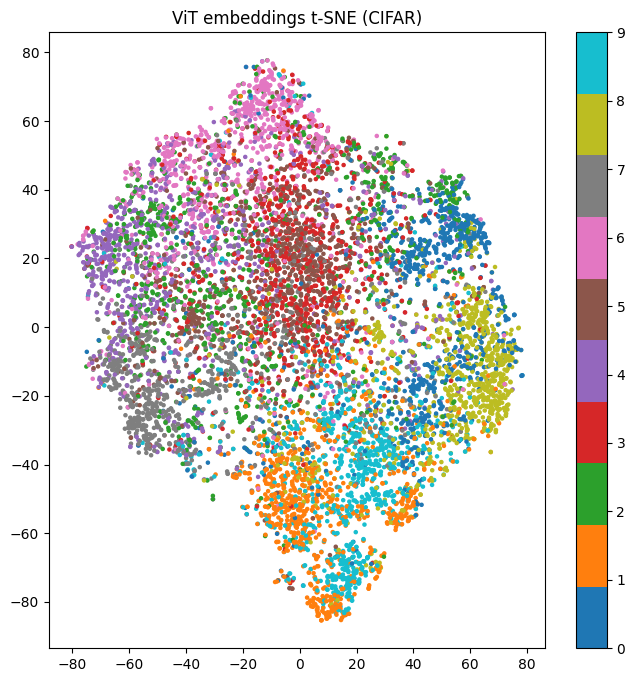

In [ ]:
vit_embs, vit_labels = extract_embeddings(vit_model, test_ds, max_batches=80)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="random",
    random_state=42,
)
vit_tsne = tsne.fit_transform(vit_embs)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    vit_tsne[:, 0],
    vit_tsne[:, 1],
    c=vit_labels,
    cmap="tab10",
    s=5,
)
plt.title("ViT embeddings t-SNE (CIFAR)")
plt.colorbar(scatter)
plt.show()

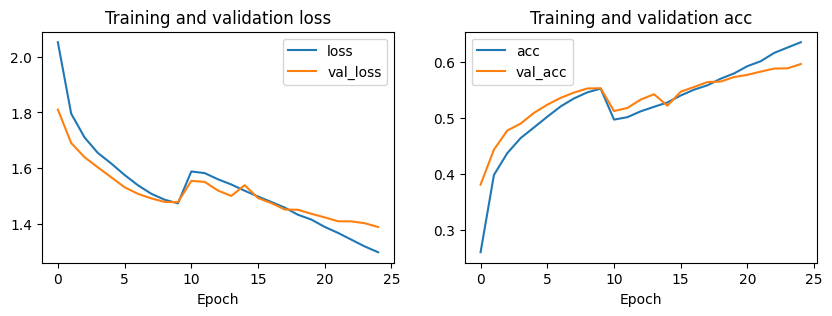

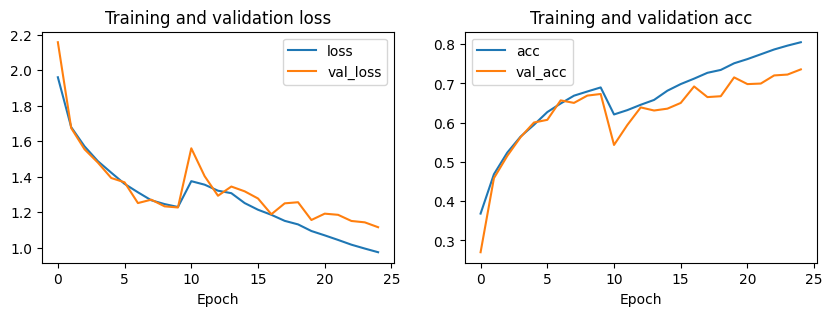

In [ ]:
plot_learning(history_vit)
plot_learning(history_resnet)

In [ ]:
#Switch to CIFAR-100
NUM_CLASSES = 100

(x_train, y_train), (x_test, y_test) = load_cifar(NUM_CLASSES)

train_ds = make_ds(x_train, y_train, training=True)
test_ds  = make_ds(x_test, y_test, training=False)

print("CIFAR-100 loaded:", x_train.shape, x_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
CIFAR-100 loaded: (50000, 32, 32, 3) (10000, 32, 32, 3)


In [ ]:
vit_model = build_vit(num_classes=NUM_CLASSES)

In [ ]:
#Rebuild ViT for CIFAR-100
vit_optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY,
    global_clipnorm=1.0,
)

vit_model.compile(
    optimizer=vit_optimizer,
    loss=loss_fn,
    metrics=metrics,
)

print("Training ViT on CIFAR-100...")
history_vit = vit_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
)

Training ViT on CIFAR-100...
Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 136s 230ms/step - acc: 0.0349 - loss: 4.3931 - val_acc: 0.0647 - val_loss: 4.1636
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 69s 177ms/step - acc: 0.0919 - loss: 4.0370 - val_acc: 0.1266 - val_loss: 3.8751
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 72s 185ms/step - acc: 0.1391 - loss: 3.8110 - val_acc: 0.1583 - val_loss: 3.7433
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 177ms/step - acc: 0.1687 - loss: 3.6712 - val_acc: 0.1774 - val_loss: 3.6427
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 179ms/step - acc: 0.1928 - loss: 3.5584 - val_acc: 0.2067 - val_loss: 3.5245
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 69s 178ms/step - acc: 0.2169 - loss: 3.4654 - val_acc: 0.2227 - val_loss: 3.4510
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 178ms/step - acc: 0.2324 - loss: 3.3891 - val_acc: 0.2355 - val_loss: 3.4071
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 175ms/step - acc: 0.2499 - loss: 3.3198 - val_acc: 0.2494 - val_loss: 3.3638
Ep

In [ ]:
#Rebuild ResNet baseline for CIFAR-100
resnet_model = build_resnet_baseline(num_classes=NUM_CLASSES)

resnet_optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY,
    global_clipnorm=1.0,
)

resnet_model.compile(
    optimizer=resnet_optimizer,
    loss=loss_fn,
    metrics=metrics,
)

print("Training ResNet on CIFAR-100...")
history_resnet, resnet_val_acc = train_and_eval(
    resnet_model, train_ds, test_ds, EPOCHS, "ResNet"
)

Training ResNet on CIFAR-100...
Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 175s 259ms/step - acc: 0.0852 - loss: 4.4554 - val_acc: 0.0540 - val_loss: 4.3393
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 67s 171ms/step - acc: 0.0859 - loss: 4.1303 - val_acc: 0.1325 - val_loss: 3.8822
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 65s 166ms/step - acc: 0.1278 - loss: 3.9235 - val_acc: 0.1713 - val_loss: 3.7068
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 169ms/step - acc: 0.1607 - loss: 3.7704 - val_acc: 0.2052 - val_loss: 3.5684
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 167ms/step - acc: 0.1907 - loss: 3.6555 - val_acc: 0.2142 - val_loss: 3.5304
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 65s 165ms/step - acc: 0.2160 - loss: 3.5562 - val_acc: 0.2523 - val_loss: 3.3978
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 64s 164ms/step - acc: 0.2399 - loss: 3.4673 - val_acc: 0.2763 - val_loss: 3.2921
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 64s 163ms/step - acc: 0.2622 - loss: 3.3806 - val_acc: 0.2852 - val_loss: 3.2457

Plotting ViT learning curves...


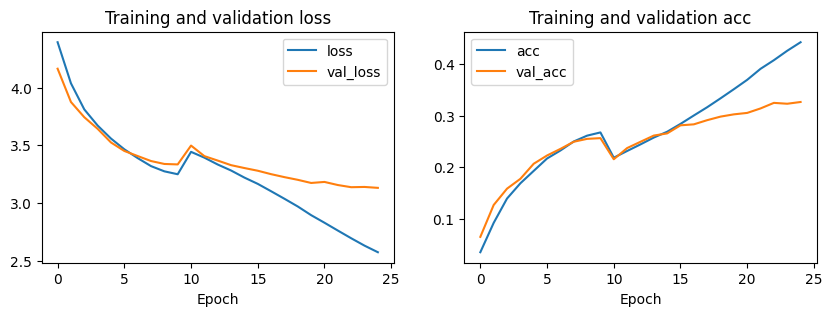

Plotting ResNet learning curves...


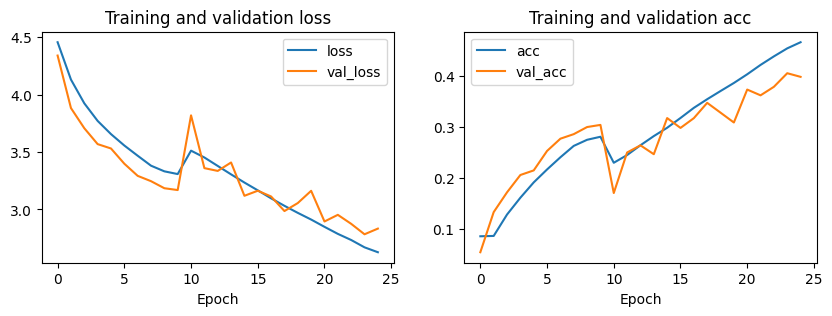

In [ ]:
print("Plotting ViT learning curves...")
plot_learning(history_vit)
plt.show()

print("Plotting ResNet learning curves...")
plot_learning(history_resnet)
plt.show()

In [ ]:
#Extract embeddings for t-SNE (ViT)

# Redefine extract_embeddings to use the correct layer name
def extract_embeddings(model, ds, max_batches=50):
    emb_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer("dense_27").output, # Changed from "dense_12" to "dense_27"
    )
    embs = []
    labels = []
    for i, (x, y) in enumerate(ds):
        if i >= max_batches:
            break
        e = emb_model.predict(x, verbose=0)
        embs.append(e)
        labels.append(tf.argmax(y, axis=1).numpy())
    embs = np.concatenate(embs, axis=0)
    labels = np.concatenate(labels, axis=0)
    return embs, labels

print("Extracting ViT embeddings...")
vit_embs, vit_labels = extract_embeddings(vit_model, test_ds, max_batches=80)


Extracting ViT embeddings...


Running t-SNE...


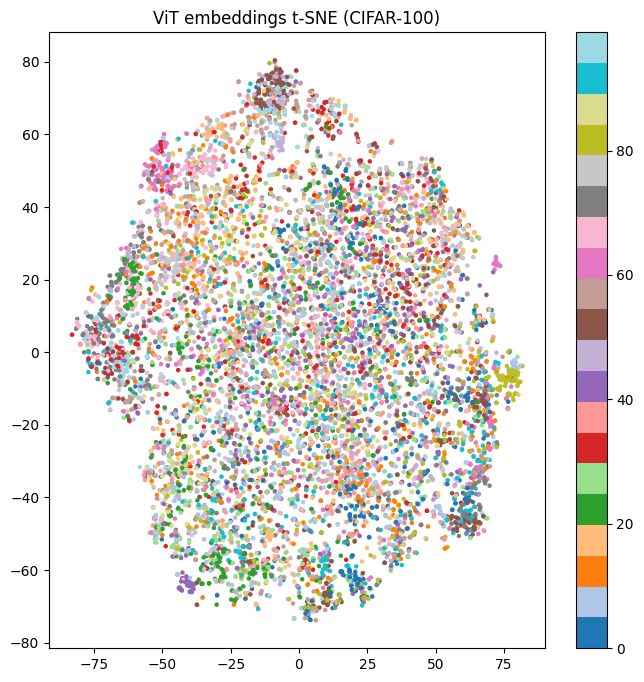

In [ ]:
#Run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="random",
    random_state=42,
)

print("Running t-SNE...")
vit_tsne = tsne.fit_transform(vit_embs)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    vit_tsne[:, 0],
    vit_tsne[:, 1],
    c=vit_labels,
    cmap="tab20",
    s=5,
)
plt.title("ViT embeddings t-SNE (CIFAR-100)")
plt.colorbar(scatter)
plt.show()